In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [48]:
df = pd.read_csv("P653_pronostico_dataset.csv", sep=';')

In [50]:
df.head()

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy


**Basic Data Analysis**

In [51]:
df.shape

(6000, 6)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB


In [53]:
df.describe()

,ID,age,systolic_bp,diastolic_bp,cholesterol
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2999.500000,60.464121,100.694822,90.505547,100.628255
std,1732.195139,8.564392,10.669267,9.648200,10.433915
min,0.000000,35.164761,69.675429,62.807105,69.967453
25%,1499.750000,54.371941,93.267420,83.641788,93.202373
50%,2999.500000,59.831159,100.119926,89.912429,100.060637
75%,4499.250000,65.809652,107.439501,96.682405,107.250829
max,5999.000000,103.279497,151.699660,133.456382,148.233544


In [54]:
df.isnull().sum()

,0
ID,0
age,0
systolic_bp,0
diastolic_bp,0
cholesterol,0
prognosis,0


In [55]:
df.duplicated().sum()

np.int64(0)

**Exploratory Data Analysis (EDA)**

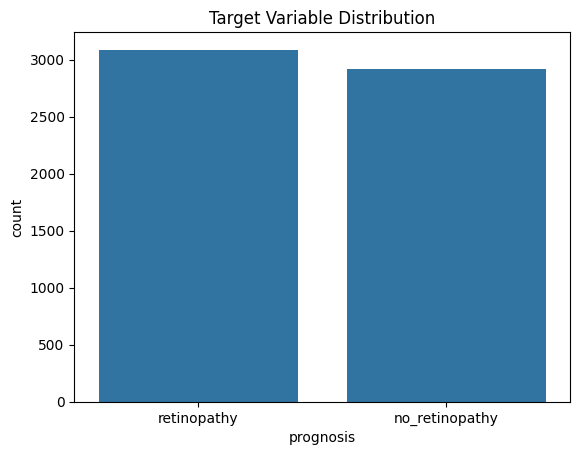

In [56]:
#Target Variable Distribution
sns.countplot(x='prognosis', data=df)
plt.title("Target Variable Distribution")
plt.show()

**Univariate Analysis (Distribution of Numerical Variables)**

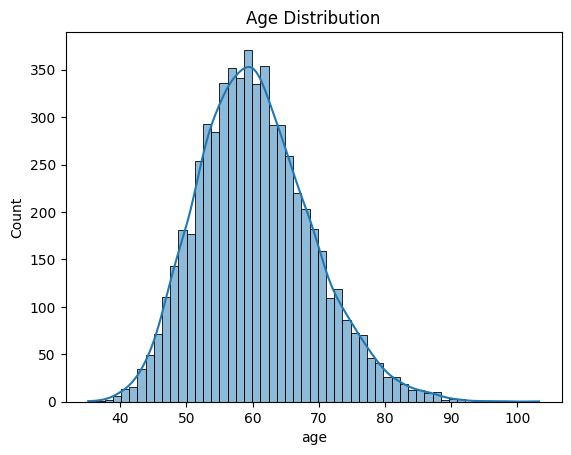

In [57]:
#Age Distribution
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()


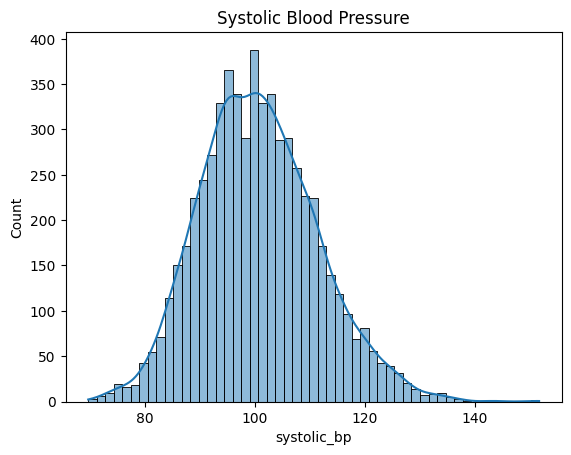

In [58]:
#Systolic BP
sns.histplot(df['systolic_bp'], kde=True)
plt.title("Systolic Blood Pressure")
plt.show()

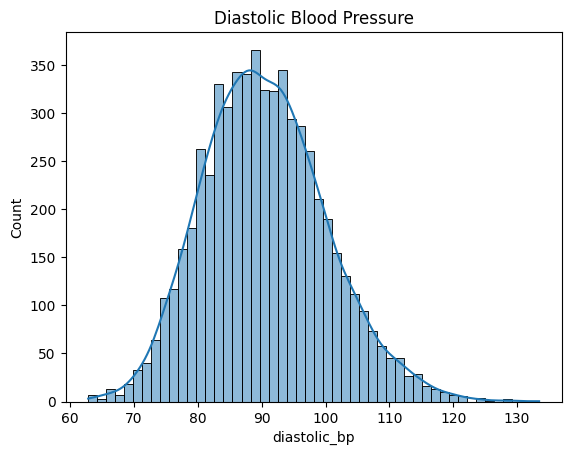

In [60]:
#Diastolic BP
sns.histplot(df['diastolic_bp'], kde=True)
plt.title("Diastolic Blood Pressure")
plt.show()

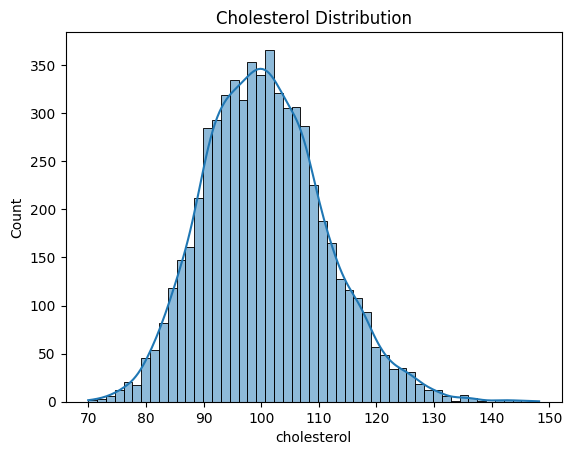

In [61]:
#Cholesterol
sns.histplot(df['cholesterol'], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

**Outlier Detection Using Boxplot**

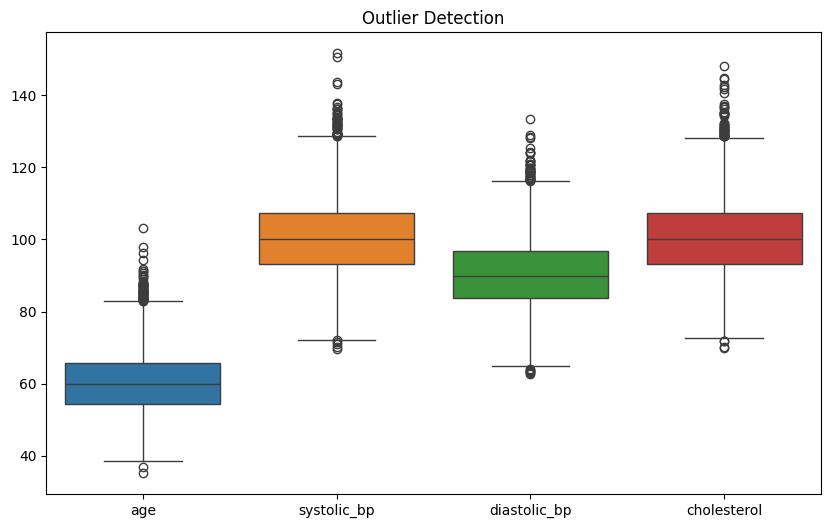

In [62]:

plt.figure(figsize=(10,6))
sns.boxplot(data=df[['age','systolic_bp','diastolic_bp','cholesterol']])
plt.title("Outlier Detection")
plt.show()


**Bivariate Analysis (Feature vs Target)**

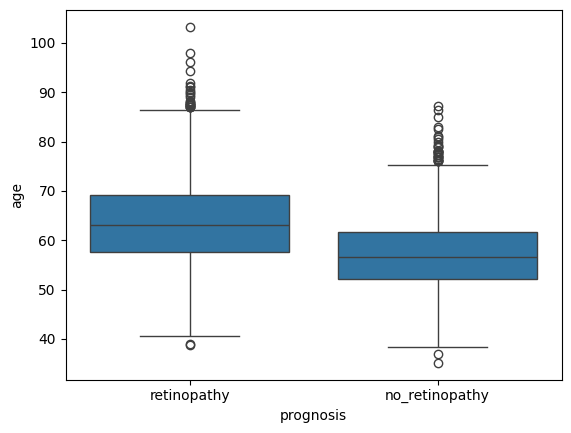

In [63]:
#Age vs Prognosis

sns.boxplot(x='prognosis', y='age', data=df)
plt.show()

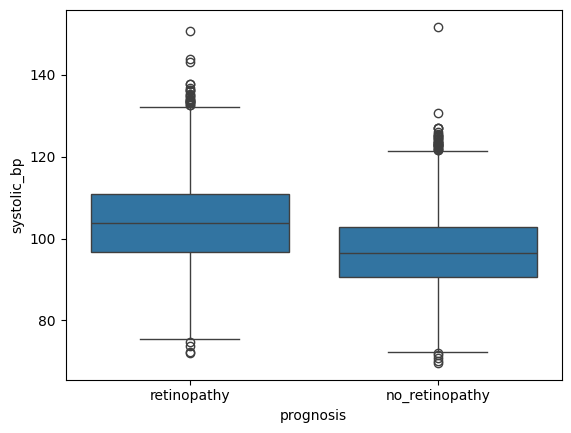

In [64]:
#Systolic BP vs Prognosis

sns.boxplot(x='prognosis', y='systolic_bp', data=df)
plt.show()

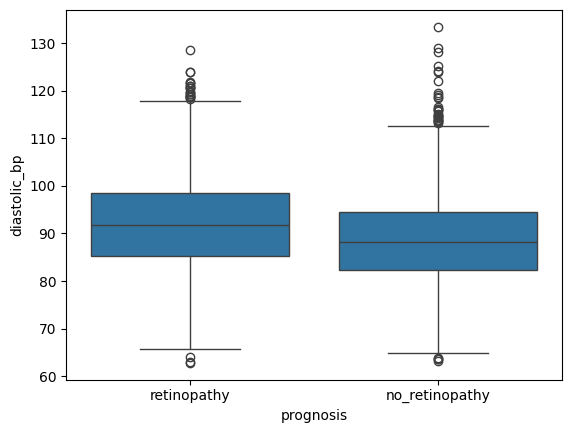

In [65]:
#Diastolic BP vs Prognosis

sns.boxplot(x='prognosis', y='diastolic_bp', data=df)
plt.show()

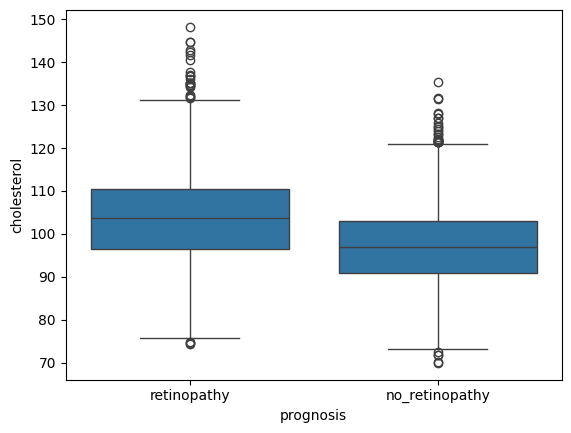

In [66]:
#Cholesterol vs Prognosis

sns.boxplot(x='prognosis', y='cholesterol', data=df)
plt.show()

**Correlation Matrix**

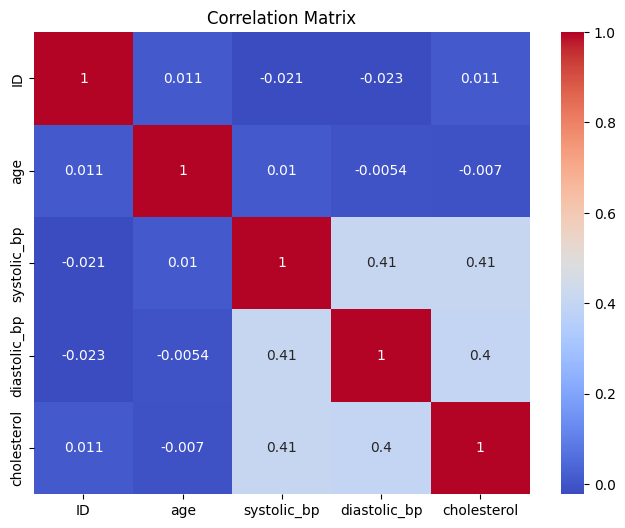

In [67]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('prognosis', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Feature Engineering**

In [73]:
# Select features and target
features = ['age', 'systolic_bp', 'diastolic_bp', 'cholesterol']

X = df[features]
y = df['prognosis']

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4800
Test size: 1200


In [74]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [75]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
df.shape

(6000, 6)

> We performed EDA to understand the dataset, check data distribution, and identify any missing values or issues in the data.
> Then, feature engineering and preprocessing were applied by selecting relevant features and scaling the data, preparing it for the next step of model building.
